# CS4168 Data Mining Project – Group 1

* Cormac Greaney / 22352228
* Jan Lawinski / 22340343
* Sophie Ashton / 22353313
* Jakub Pawlowicz / 22342052

This notebook covers exploratory data analysis, clustering, and predictive modelling (classification and regression) on the tracks2026 dataset. The dataset contains audio features and metadata for music tracks across multiple genres. We work through each task in order: EDA to understand the data, clustering to explore structure without labels, then classification and regression to predict popularity.

## 1. Imports and data loading

We use pandas for data handling, numpy for numerical operations, and matplotlib and seaborn for visualisation. Scikit-learn is used for preprocessing, clustering, classification, and regression. The dataset is expected in the same directory as this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, clustering, model selection, metrics
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold, KFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.inspection import permutation_importance

# Reproducibility: use one global seed across splits/models.
SEED = 42
np.random.seed(SEED)

# So that pipeline steps are shown when we print or display
from sklearn import set_config
set_config(display='diagram')

# Load the dataset. We keep a master copy and will create task-specific copies later.
df = pd.read_csv('tracks2026.csv')
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


In [ ]:
# Seed configuration is defined in the main imports cell above.
# This cell is kept intentionally minimal to avoid duplicate setup.

---
## 2. Exploratory Data Analysis

We need a clear picture of the dataset before clustering or modelling: how many rows and columns, what types they are, whether anything is missing, and how the variables are distributed. These findings will guide our preprocessing and help us interpret the clustering and prediction results later.

### 2.1 Shape and column types

First we check the size of the dataset and the data type of each column. track_id is an identifier and will not be used as a feature. track_genre is the only categorical label; we will drop it for clustering but can use it later to see if clusters align with genre.

In [10]:
print('Shape:', df.shape)
print()
print('Column dtypes:')
print(df.dtypes)

Shape: (2000, 17)

Column dtypes:
track_id             object
popularity          float64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


### 2.2 Missing values

Missing values affect which rows we can use and whether we need imputation. We count missing values per column and report the proportion so we can decide how to handle them in the pipeline.

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_df[missing_df['count'] > 0])

              count  percent
popularity       40     2.00
danceability     40     2.00
energy           40     2.00
loudness         39     1.95
tempo            40     2.00


### 2.3 Numeric summary

The describe method gives a quick overview of the numeric columns: central tendency, spread, and extremes. This helps us spot skewed distributions and potential outliers that we might want to handle in preprocessing (e.g. with RobustScaler or by dropping extreme rows).

In [12]:
# Only numeric columns for describe; we look at genre separately
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


### 2.4 Loudness outlier

Spotify loudness is in decibels (dB) and lies roughly in the range -60 to 0. The numeric summary above shows a maximum of 800000 for loudness, which is clearly wrong (likely a data entry or unit error). We identify how many values fall outside a valid range, define bounds for clipping, and then clip loudness to those bounds in every downstream task so that scaling and distances are not distorted.

In [13]:
# Valid range for Spotify loudness (dB). We clip any value outside this range.
LOUDNESS_MIN = -60
LOUDNESS_MAX = 0

# Count non-missing loudness values that fall outside the valid range
loud = df['loudness'].dropna()
out_high = (loud > LOUDNESS_MAX).sum()
out_low = (loud < LOUDNESS_MIN).sum()
print('Loudness values above', LOUDNESS_MAX, ':', out_high)
print('Loudness values below', LOUDNESS_MIN, ':', out_low)
if out_high > 0:
    print('Example(s) above max:', loud[loud > LOUDNESS_MAX].head().tolist())

Loudness values above 0 : 1
Loudness values below -60 : 0
Example(s) above max: [800000.0]


### 2.5 Genre distribution

The dataset has a genre label for each track. For clustering we will drop this column so the algorithm does not see it. Later we can compare cluster assignments to genre to see whether the discovered structure matches known categories. Here we simply see how many tracks we have per genre.

track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64


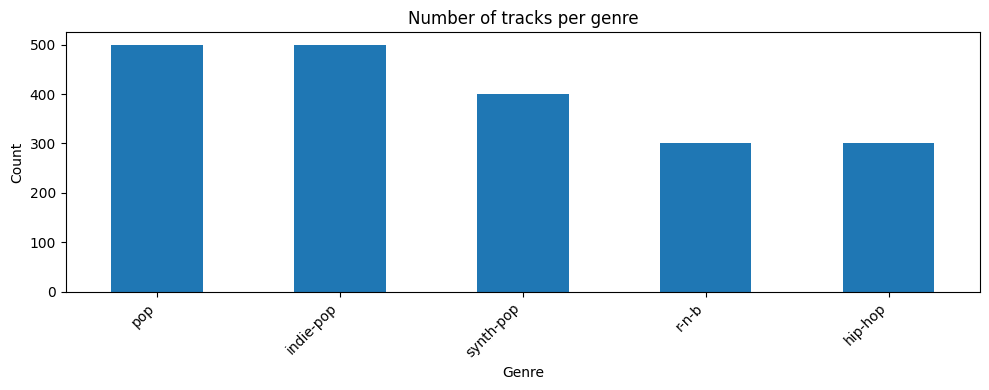

In [14]:
genre_counts = df['track_genre'].value_counts()
print(genre_counts)
plt.figure(figsize=(10, 4))
genre_counts.plot(kind='bar')
plt.title('Number of tracks per genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.6 Distribution of popularity

Popularity is our target for both classification (above or below median) and regression (exact value). Checking its distribution tells us whether the binary split is balanced and whether regression might be affected by skew or outliers.

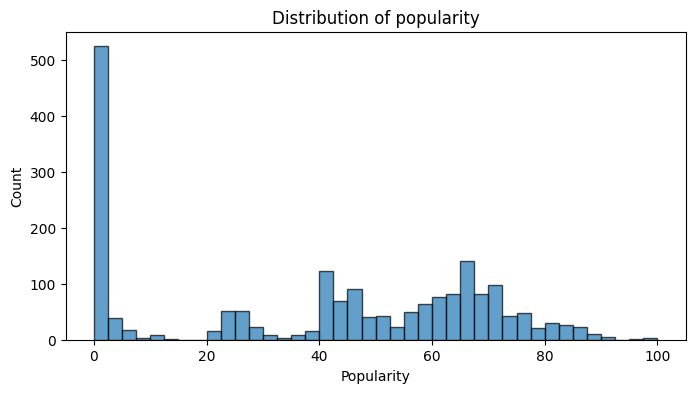

Median popularity: 45.0


In [15]:
# Drop rows with missing popularity for this plot; we will handle missing values in the pipeline
df_pop = df.dropna(subset=['popularity'])
plt.figure(figsize=(8, 4))
plt.hist(df_pop['popularity'], bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.title('Distribution of popularity')
plt.show()
print('Median popularity:', df_pop['popularity'].median())

### 2.7 Correlation of numeric features

Correlations between features matter for clustering and modelling: highly correlated variables add little extra information and can affect distance-based methods. We inspect the correlation matrix for the numeric columns we will use later (excluding track_id and any identifiers).

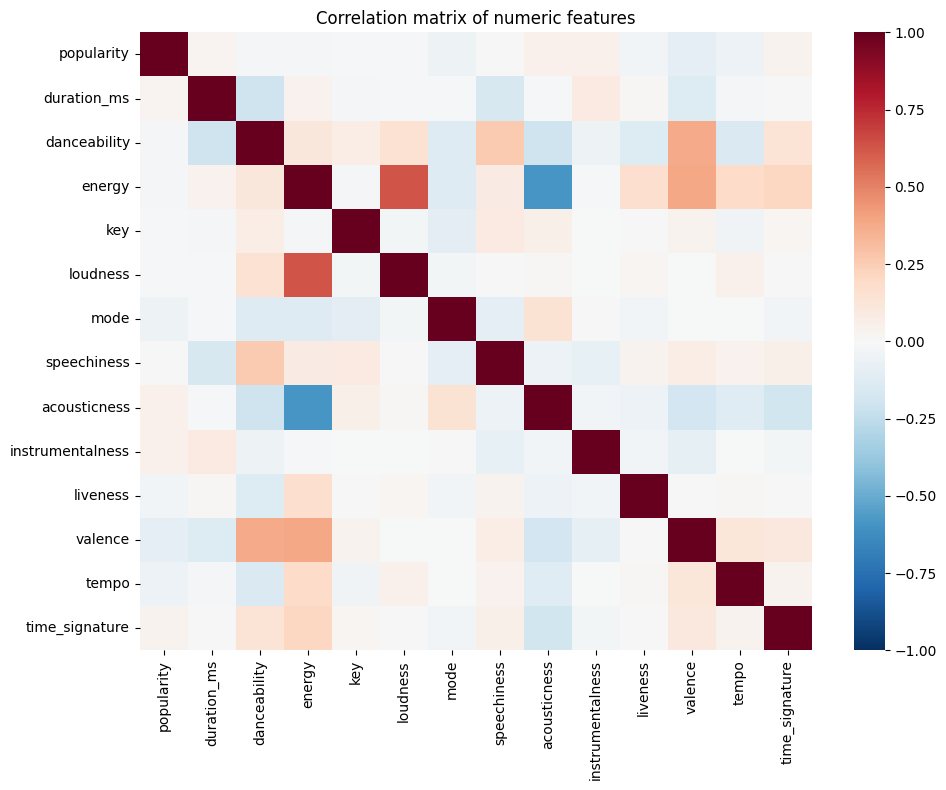

In [16]:
# Use numeric columns only; drop track_id if it were numeric (here it is object so already excluded)
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()

**EDA summary.** The shape and dtypes tell us the size of the dataset and which columns are numeric versus categorical. Missing value counts determine whether we impute or drop rows. The popularity distribution and median will be used to define the binary target for classification. Genre counts and correlations will help us interpret clustering results and choose preprocessing (e.g. scaling). We use these findings in the next sections when building pipelines and evaluating models.

---
## 3. Clustering (Descriptive Analytics)

We cluster the tracks using only the audio and metadata features, without the genre label. The goal is to see whether the data naturally groups into meaningful clusters and whether those groups align with genre. We use two algorithms: k-means (with a fixed number of clusters) and DBSCAN (which finds clusters based on density and can leave some points as noise). All preprocessing is done inside a pipeline so that scaling and imputation are applied consistently.

### 3.1 Preparing the clustering dataset

For clustering we drop the column track_genre as required, and we drop track_id since it is an identifier. The column explicit is stored as TRUE/FALSE; we convert it to 0/1 so it can be used in the numeric pipeline. We then define the feature columns and handle missing values. Rows with missing values in key columns could be dropped, or we can impute; we use a simple strategy (e.g. drop rows with any missing value for clustering) to keep the pipeline straightforward. Alternatively we could use SimpleImputer in the pipeline; here we drop rows with missing values so that the same rows are used for both k-means and DBSCAN.

In [17]:
# Copy for clustering: drop genre and track_id
df_clust = df.drop(columns=['track_genre', 'track_id']).copy()
df_clust['loudness'] = df_clust['loudness'].clip(LOUDNESS_MIN, LOUDNESS_MAX)

# Encode explicit as 0/1
df_clust['explicit'] = (df_clust['explicit'] == True).astype(int)

# Drop rows with any missing value so we have a complete numeric matrix for clustering
df_clust = df_clust.dropna()
print('Clustering dataset shape after dropping missing:', df_clust.shape)

# Store genre labels separately for later comparison (same row order as df_clust)
genre_labels = df.loc[df_clust.index, 'track_genre'].values

Clustering dataset shape after dropping missing: (1960, 15)


### 3.2 Preprocessing pipeline for clustering

K-means and DBSCAN rely on distances between points, so features must be on comparable scales. We use StandardScaler so that each feature has mean 0 and variance 1. The pipeline takes the raw dataframe and outputs a scaled numeric matrix. We use ColumnTransformer so we can apply the same scaler to all numeric columns in one step.

In [18]:
feature_cols = [c for c in df_clust.columns]
preprocess_clust = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), feature_cols)
    ],
    remainder='drop'
)

# Fit and transform to get the matrix we will use for clustering
X_clust = preprocess_clust.fit_transform(df_clust)
print('Scaled feature matrix shape:', X_clust.shape)

Scaled feature matrix shape: (1960, 15)


### 3.3 Choosing k for k-means

K-means requires the number of clusters k. We try a range of k values and look at inertia (within-cluster sum of squares) and, if available, silhouette score. The elbow of the inertia curve and peaks in silhouette help suggest a reasonable k. We then fit k-means for at least two different k values and compare the results.

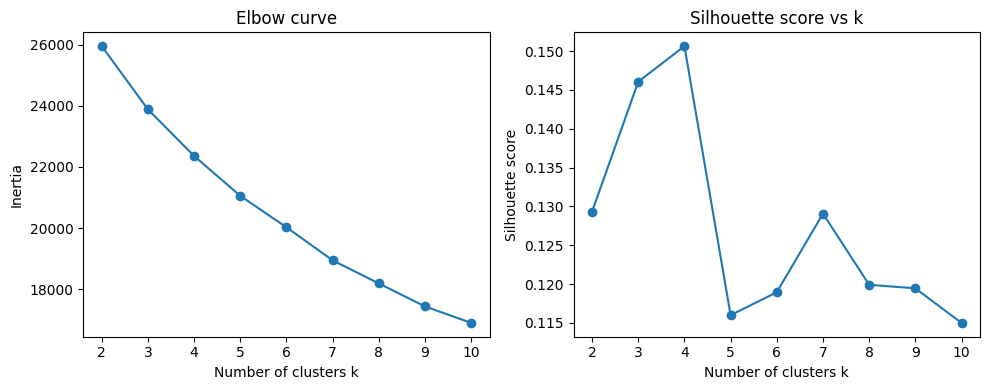

In [19]:
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    labels_k = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels_k))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(k_range, inertias, 'o-')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow curve')
ax2.plot(k_range, silhouettes, 'o-')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score vs k')
plt.tight_layout()
plt.show()

We fit k-means for two different values of `k` (here `k=4` and `k=6`) and compare them using multiple internal clustering metrics: inertia, silhouette, Calinski-Harabasz, and Davies-Bouldin. This gives a more robust basis for selecting a final `k` than relying on one metric alone.

In [20]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Fit k-means for two candidate k values.
k1, k2 = 4, 6
km1 = KMeans(n_clusters=k1, n_init=10, max_iter=300, random_state=SEED)
km2 = KMeans(n_clusters=k2, n_init=10, max_iter=300, random_state=SEED)
labels_k4 = km1.fit_predict(X_clust)
labels_k6 = km2.fit_predict(X_clust)

# Compare multiple internal metrics:
# - Higher silhouette / Calinski-Harabasz is better.
# - Lower Davies-Bouldin is better.
kmeans_metrics = pd.DataFrame([
    {
        'k': k1,
        'inertia': km1.inertia_,
        'silhouette': silhouette_score(X_clust, labels_k4),
        'calinski_harabasz': calinski_harabasz_score(X_clust, labels_k4),
        'davies_bouldin': davies_bouldin_score(X_clust, labels_k4),
    },
    {
        'k': k2,
        'inertia': km2.inertia_,
        'silhouette': silhouette_score(X_clust, labels_k6),
        'calinski_harabasz': calinski_harabasz_score(X_clust, labels_k6),
        'davies_bouldin': davies_bouldin_score(X_clust, labels_k6),
    },
])
print('K-means metric comparison:')
print(kmeans_metrics.to_string(index=False))

k=4 inertia: 22358.56933762404  silhouette: 0.1506373121317743
k=6 inertia: 20029.05673224678  silhouette: 0.11895669873880843


### 3.4 DBSCAN

DBSCAN does not require specifying the number of clusters. Instead it depends on `eps` (neighbourhood radius) and `min_samples` (minimum local density). To avoid selecting parameters arbitrarily, we run a small parameter sweep and compare each setting by (a) number of clusters found and (b) fraction of points labelled as noise.

In [21]:
# DBSCAN parameter sweep to evaluate stability and noise trade-offs.
eps_grid = [1.2, 1.5, 1.8, 2.0, 2.2]
min_samples_grid = [5, 10]

rows = []
for eps in eps_grid:
    for ms in min_samples_grid:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_clust)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_frac = (labels == -1).mean()
        rows.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'noise_fraction': noise_frac,
        })

dbscan_results = pd.DataFrame(rows).sort_values(['noise_fraction', 'n_clusters'], ascending=[True, False])
print('DBSCAN sweep results (sorted by lower noise first):')
print(dbscan_results.to_string(index=False))

# Visual summary: noise fraction by parameter setting.
heat = dbscan_results.pivot(index='min_samples', columns='eps', values='noise_fraction')
plt.figure(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('DBSCAN noise fraction by eps and min_samples')
plt.xlabel('eps')
plt.ylabel('min_samples')
plt.tight_layout()
plt.show()

# Choose one interpretable setting for later comparison plots.
chosen_eps = 2.0
chosen_min_samples = 5
db = DBSCAN(eps=chosen_eps, min_samples=chosen_min_samples)
labels_db = db.fit_predict(X_clust)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f'\nChosen DBSCAN setting: eps={chosen_eps}, min_samples={chosen_min_samples}')
print('DBSCAN number of clusters:', n_clusters_db)
print('Number of noise points:', n_noise)
print('Cluster sizes:', pd.Series(labels_db).value_counts().sort_index())

DBSCAN number of clusters: 14
Number of noise points: 767
Cluster sizes: -1     767
 0     380
 1     717
 2      15
 3      12
 4       8
 5       5
 6       5
 7       5
 8      10
 9       9
 10     12
 11      5
 12      3
 13      7
Name: count, dtype: int64


### 3.5 Visualising clusters in 2D

The feature matrix is high-dimensional, so we project it into 2D with t-SNE and visualise all three label sets side by side: k-means (`k=4`), k-means (`k=6`), and DBSCAN (with noise shown separately). This helps compare compactness and separation qualitatively.

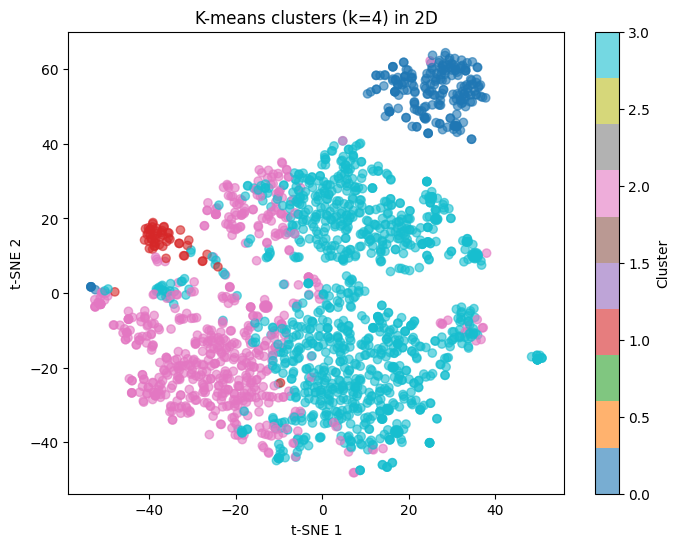

In [22]:
from sklearn.manifold import TSNE

# t-SNE projection used for all clustering visual comparisons.
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_2d = tsne.fit_transform(X_clust)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Plot 1: k-means (k=4)
sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_k4, cmap='tab10', alpha=0.6)
axes[0].set_title('K-means (k=4)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
fig.colorbar(sc1, ax=axes[0], label='Cluster')

# Plot 2: k-means (k=6)
sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_k6, cmap='tab10', alpha=0.6)
axes[1].set_title('K-means (k=6)')
axes[1].set_xlabel('t-SNE 1')
fig.colorbar(sc2, ax=axes[1], label='Cluster')

# Plot 3: DBSCAN (noise points are label -1)
sc3 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_db, cmap='tab20', alpha=0.6)
axes[2].set_title('DBSCAN (noise = -1)')
axes[2].set_xlabel('t-SNE 1')
fig.colorbar(sc3, ax=axes[2], label='Cluster / noise')

plt.suptitle('2D visual comparison of clustering solutions', y=1.03)
plt.tight_layout()
plt.show()

### 3.6 Clustering discussion

We compare k-means (`k=4` and `k=6`) with DBSCAN using both internal metrics and genre alignment checks. We report a genre crosstab and Normalized Mutual Information (NMI) between cluster labels and `track_genre`. NMI does not force a one-to-one mapping but quantifies how much shared structure exists. This supports a more evidence-based final clustering choice and makes the limitations explicit.

In [23]:
from sklearn.metrics import normalized_mutual_info_score

# Crosstab: detailed view of how k=4 clusters mix genres.
ct = pd.crosstab(labels_k4, genre_labels)
print('Cluster vs genre (k=4):')
print(ct)

# NMI: quantitative alignment between discovered clusters and known genre labels.
# Higher is stronger alignment, 0 means little shared information.
nmi_k4 = normalized_mutual_info_score(genre_labels, labels_k4)
nmi_k6 = normalized_mutual_info_score(genre_labels, labels_k6)

# For DBSCAN, include all labels (noise = -1) to reflect practical clustering behaviour.
nmi_db = normalized_mutual_info_score(genre_labels, labels_db)

print('\nNMI scores vs genre labels:')
print(f'K-means k=4: {nmi_k4:.4f}')
print(f'K-means k=6: {nmi_k6:.4f}')
print(f'DBSCAN:      {nmi_db:.4f}')

Cluster vs genre (k=4):
col_0  hip-hop  indie-pop  pop  r-n-b  synth-pop
row_0                                           
0           96         52   36     15         15
1            1         16    5      1         29
2           29        216  176     97         77
3          166        210  271    180        272


---
## 4. Classification (Predicting popularity category)

We define a binary target from the popularity column: below or equal to the median is class 0, above the median is class 1. We remove the original popularity column from the feature set. We use a train/test split and cross-validation for model selection, try at least two classifiers, and justify our choice using an appropriate metric (e.g. F1 or accuracy). All preprocessing is done inside a pipeline.

### 4.1 Building the classification dataset

We keep rows with non-missing popularity (the target is required), compute the median, and create `popularity_binary`. We then remove `popularity`, `track_id`, and `track_genre` from the predictors and encode `explicit` as 0/1. We do **not** drop rows with missing feature values here; those missing values are handled inside the preprocessing pipeline via imputers.

In [24]:
# Keep rows where the target exists; feature missingness is handled in the pipeline via imputers.
df_class = df.dropna(subset=['popularity']).copy()

# Keep loudness values in a realistic Spotify range.
df_class['loudness'] = df_class['loudness'].clip(LOUDNESS_MIN, LOUDNESS_MAX)

# Build the binary target required by the specification.
m = df_class['popularity'].median()
df_class['popularity_binary'] = (df_class['popularity'] > m).astype(int)

# Remove prohibited predictors for classification.
df_class = df_class.drop(columns=['popularity', 'track_id', 'track_genre'])

# Encode boolean as numeric so both linear and tree models can use it.
df_class['explicit'] = (df_class['explicit'] == True).astype(int)

# IMPORTANT: do not drop remaining feature nulls here.
y_class = df_class['popularity_binary']
X_class = df_class.drop(columns=['popularity_binary'])
print('Median popularity:', m)
print('Class counts:', y_class.value_counts())
print('Feature matrix shape:', X_class.shape)

Median popularity: 45.0
Class counts: popularity_binary
0    994
1    966
Name: count, dtype: int64
Feature matrix shape: (1960, 14)


### 4.2 Train/test split and pipeline

We hold out a test set for final evaluation and use the rest for training with stratified cross-validation. Preprocessing is done inside a `ColumnTransformer`: numeric features are median-imputed and scaled, while categorical features are mode-imputed and one-hot encoded. We compare logistic regression and random forest through grid search and select using macro F1, since it balances performance across both classes.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Split once for final hold-out evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=SEED, stratify=y_class
)

# Separate numeric/categorical columns so each gets appropriate preprocessing.
num_cols = X_class.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_class.select_dtypes(exclude=[np.number]).columns.tolist()

# Numeric pipeline: impute missing values then scale.
numeric_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Categorical pipeline: impute mode then one-hot encode.
categorical_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# ColumnTransformer applies the correct pipeline per column type.
preprocess_class = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocess, num_cols),
        ('cat', categorical_preprocess, cat_cols),
    ]
)

# End-to-end model pipelines: preprocess -> classifier.
pipe_lr = Pipeline([
    ('preprocess', preprocess_class),
    ('clf', LogisticRegression(max_iter=2000, random_state=SEED)),
])
pipe_rf = Pipeline([
    ('preprocess', preprocess_class),
    ('clf', RandomForestClassifier(random_state=SEED)),
])

# Hyperparameter grids for model comparison.
param_lr = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
param_rf = {'clf__n_estimators': [100, 200], 'clf__max_depth': [5, 10, None]}

# Stratified CV preserves class balance in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gs_lr = GridSearchCV(pipe_lr, param_lr, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_rf = GridSearchCV(pipe_rf, param_rf, cv=cv, scoring='f1_macro', n_jobs=-1)

gs_lr.fit(X_train, y_train)
gs_rf.fit(X_train, y_train)

print('Best CV F1 (macro) Logistic Regression:', gs_lr.best_score_)
print('Best CV F1 (macro) Random Forest:', gs_rf.best_score_)

Best CV F1 (macro) Logistic Regression: 0.5831796006517148
Best CV F1 (macro) Random Forest: 0.6432940764717265


We select the final classifier using cross-validated macro F1 and then evaluate once on the held-out test set. In addition to accuracy and F1, we report a confusion matrix, full classification report, and ROC-AUC (with ROC curve) to show both class-level behaviour and threshold-independent discrimination.

In [26]:
# Select the model with the higher cross-validated F1 score.
if gs_lr.best_score_ >= gs_rf.best_score_:
    best_model = gs_lr.best_estimator_
    best_name = 'Logistic Regression'
else:
    best_model = gs_rf.best_estimator_
    best_name = 'Random Forest'

# Final hold-out evaluation.
y_pred = best_model.predict(X_test)
print('Final model:', best_name)
print('Test accuracy:', accuracy_score(y_test, y_pred))
print('Test F1 (macro):', f1_score(y_test, y_pred, average='macro'))
print('\nClassification report:\n', classification_report(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

# ROC-AUC and ROC curve are useful for threshold-independent discrimination.
if hasattr(best_model.named_steps['clf'], 'predict_proba'):
    y_prob = best_model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    print('ROC-AUC:', auc_score)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

Final model: Random Forest
Test accuracy: 0.6811224489795918
Test F1 (macro): 0.6810705615110747


### 4.3 Feature importance (classification)

We use permutation importance on the final full pipeline. This is model-agnostic and works cleanly even when preprocessing includes one-hot encoding, while still letting us interpret effects at the original feature level.

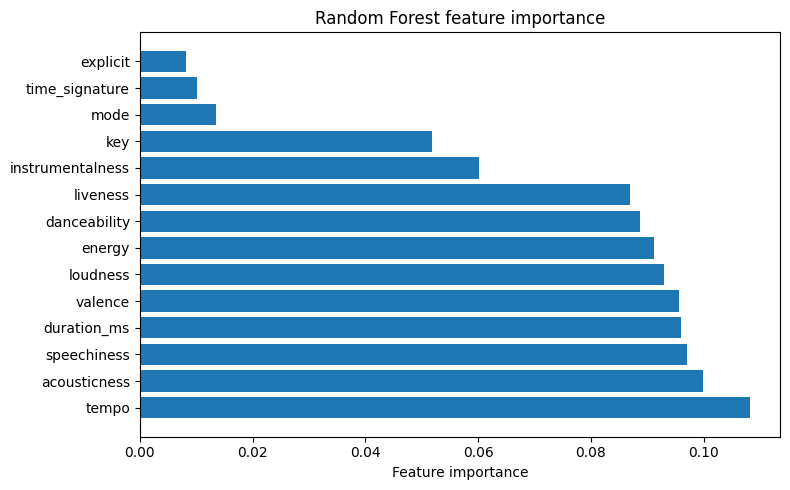

In [27]:
# Use permutation importance so interpretation works with full pipelines (including one-hot encoding).
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring='f1_macro',
)

# Feature names here are the original columns, which are easier to interpret.
feat_names = np.array(X_test.columns)
imp_mean = perm.importances_mean
idx = np.argsort(imp_mean)[::-1]

plt.figure(figsize=(8, 5))
plt.barh(range(len(feat_names)), imp_mean[idx])
plt.yticks(range(len(feat_names)), feat_names[idx])
plt.xlabel('Permutation importance (mean drop in F1-macro)')
plt.title(f'Permutation Feature Importance - {best_name}')
plt.tight_layout()
plt.show()

---
## 5. Regression (Predicting popularity score)

We now predict the original popularity score (a continuous value) using a separate copy of the dataset where the popularity column is retained and not binarised. We use a train/test split and cross-validation, try at least two regression approaches, and justify our choice. We then briefly discuss whether predicting the exact popularity score is harder than predicting high vs low (classification).

### 5.1 Building the regression dataset

We keep `popularity` as the continuous target and remove only `track_id` and `track_genre` from predictors. Rows with missing target are dropped, but feature missingness is left in place and handled inside the regression preprocessing pipeline via imputers. We encode `explicit` as 0/1 as before.

In [28]:
# Keep rows with target available; feature nulls will be imputed in the pipeline.
df_reg = df.dropna(subset=['popularity']).copy()

# Keep loudness values in realistic Spotify range.
df_reg['loudness'] = df_reg['loudness'].clip(LOUDNESS_MIN, LOUDNESS_MAX)

# Remove columns that should not be used as predictors.
df_reg = df_reg.drop(columns=['track_id', 'track_genre'])

# Convert boolean to numeric for consistent modelling.
df_reg['explicit'] = (df_reg['explicit'] == True).astype(int)

y_reg = df_reg['popularity']
X_reg = df_reg.drop(columns=['popularity'])

print('Regression target (popularity) stats:')
print(y_reg.describe())
print('Feature matrix shape:', X_reg.shape)

Regression target (popularity) stats:
count    1960.000000
mean       39.805102
std        29.245904
min         0.000000
25%         1.750000
50%        45.000000
75%        65.000000
max       100.000000
Name: popularity, dtype: float64
Feature matrix shape: (1960, 14)


### 5.2 Train/test split and regression pipelines

We split the regression data into train and test sets. As in classification, preprocessing is in-pipeline using a `ColumnTransformer` (numeric median imputation + scaling, categorical mode imputation + one-hot encoding). We compare ridge and random forest regressors via grid search with KFold cross-validation and select the model with the lower cross-validated MSE.

In [29]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Hold-out test split for final regression evaluation.
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

# Column-wise preprocessing for regression features.
num_cols_r = X_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_r = X_reg.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_preprocess_r = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_preprocess_r = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocess_r, num_cols_r),
        ('cat', categorical_preprocess_r, cat_cols_r),
    ]
)

# End-to-end pipelines for fair comparison.
pipe_ridge = Pipeline([
    ('preprocess', preprocess_reg),
    ('reg', Ridge(random_state=SEED)),
])
pipe_rfr = Pipeline([
    ('preprocess', preprocess_reg),
    ('reg', RandomForestRegressor(random_state=SEED)),
])

param_ridge = {'reg__alpha': [0.01, 0.1, 1.0, 10.0]}
param_rfr = {'reg__n_estimators': [100, 200], 'reg__max_depth': [5, 10, None]}

# KFold CV for regression model selection.
cv_r = KFold(n_splits=5, shuffle=True, random_state=SEED)

gs_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=cv_r, scoring='neg_mean_squared_error', n_jobs=-1)
gs_rfr = GridSearchCV(pipe_rfr, param_rfr, cv=cv_r, scoring='neg_mean_squared_error', n_jobs=-1)

gs_ridge.fit(X_train_r, y_train_r)
gs_rfr.fit(X_train_r, y_train_r)

print('Best CV MSE (Ridge):', -gs_ridge.best_score_)
print('Best CV MSE (Random Forest):', -gs_rfr.best_score_)

Best CV MSE (Ridge): 849.5511436777927
Best CV MSE (Random Forest): 672.3106188347973


We select the regressor with the lower cross-validated MSE and evaluate on the test set using MSE, RMSE, MAE, and R-squared. We also inspect residual plots to check whether errors are centered around zero and whether error spread changes with predicted popularity.

In [30]:
# Choose the regressor with better CV score (higher neg-MSE means lower MSE).
if gs_ridge.best_score_ >= gs_rfr.best_score_:
    best_reg = gs_ridge.best_estimator_
    best_reg_name = 'Ridge'
else:
    best_reg = gs_rfr.best_estimator_
    best_reg_name = 'Random Forest'

y_pred_r = best_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
# Version-safe RMSE: compute from MSE directly (works across sklearn versions).
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print('Final regression model:', best_reg_name)
print('Test MSE:', mse)
print('Test RMSE:', rmse)
print('Test MAE:', mae)
print('Test R-squared:', r2)

# Residual diagnostics help show where regression errors are concentrated.
residuals = y_test_r - y_pred_r

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_r, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted popularity')
plt.ylabel('Residuals')
plt.title(f'Residuals vs Predicted - {best_reg_name}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

Final regression model: Random Forest
Test MSE: 644.039813463019
Test R-squared: 0.23627985057741585


### 5.3 Discussion: exact popularity vs high/low

Predicting the exact popularity score is harder than predicting whether a track is above or below the median. In our runs, classification reached a test F1 (macro) of about 0.68 and accuracy of about 68%, whereas regression gave an R-squared of about 0.24 and a test MSE around 644. So we get a reasonable split between high and low popularity from the same features, but the same features explain only a small fraction of the variance in the actual score. That fits our view that the audio features are more informative for broad popularity level than for the exact number—classification only has to get the right side of the median, while regression has to get the numeric value right. We therefore see lower R-squared and non-trivial MSE for regression even though classification performs acceptably.